[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Favioleiva/gpubma/blob/main/examples/BFG_User_Dataset_Example.ipynb)

# BFG for your dataset

Change DATA_PATH, TARGET and EXPLANATORY_VARIABLES below, then Run all. Optional ALWAYS_IN, BUDGET, DEVICE and SEED control the run. CSV, Parquet and Stata .dta are supported. The notebook never substitutes a toy dataset for your own data.

Fresh Colab runtime; CPU or GPU. Figures reuse the recovered BFG and publication designs. All discovery weights condition on the evaluated set E and are not global PMP/PIP.

## One user configuration cell

**BUDGET is the maximum number of unique candidate models BFG may score.** It maps to the shared `BFGConfig.budget_models` cap. The search may stop earlier, including when the full candidate space has fewer models.

Optional budget choices: `1_000`, `5_000`, `10_000`, `50_000`. They are examples, not an automatically executed ladder.

In [4]:
from pathlib import Path

DATA_PATH = Path("bfg_large_demo_p30.csv")
TARGET = "y"

EXPLANATORY_VARIABLES = [
    f"x{i}" for i in range(1, 31)
]

ALWAYS_IN = []

In [2]:
BUDGET = 5000
SEED = 12345
DEVICE = "auto"

## Install and display the runtime

The reviewed release candidate is bundled transparently for validation before publication. It contains the public plotting/reporting modules and the compact archived p30 reference. No hidden helper copy or local source checkout is needed. The alternative branch runs the canonical GitHub pip-install command once these changes are publicly incorporated. Ordinary dependencies may require network installation.

In [3]:
import importlib.metadata
import importlib.util
import subprocess
import sys

# ============================================================
# Install gpubma from the public repository
# ============================================================

GPUBMA_REF = "main"

requirements = {
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.1",
    "scipy": "scipy>=1.11",
    "torch": "torch>=2.2",
    "matplotlib": "matplotlib>=3.7",
    "pyarrow": "pyarrow>=14",
}

missing = [
    requirement
    for module, requirement in requirements.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *missing,
        ],
        check=True,
    )

# Install only if gpubma is not already available.
if importlib.util.find_spec("gpubma") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            (
                "gpubma @ "
                "git+https://github.com/Favioleiva/"
                f"gpubma.git@{GPUBMA_REF}"
            ),
        ],
        check=True,
    )

import gpubma

from gpubma.bfg.example_workflow import (
    print_environment,
    ensure_public_data,
    load_example_data,
    fit_example,
    export_example,
)

environment = print_environment(DEVICE)

print(
    "gpubma",
    importlib.metadata.version("gpubma"),
    "— runtime ready"
)

Python: 3.13.15
gpubma: 0.3.0rc1
PyTorch: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
selected device: cuda
gpubma 0.3.0rc1 — runtime ready


## Load the dataset without changing the sample

Canonical examples verify the exact repository file SHA-256, fetching from public GitHub only if absent. Generic user data are uploaded when needed. No implicit dropping, imputation, dummy construction or transformation occurs. Always-in controls and candidate columns must be distinct.

In [5]:
from IPython.display import display
import matplotlib.pyplot as plt
get_ipython().run_line_magic("matplotlib", "inline")
if not DATA_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError("Supply your file at DATA_PATH") from exc
    uploaded = files.upload()
    if set(uploaded) != {DATA_PATH.name}:
        raise ValueError("Upload exactly the configured dataset")
    if not DATA_PATH.exists():
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        DATA_PATH.write_bytes(uploaded[DATA_PATH.name])
y, X, controls = load_example_data(DATA_PATH, TARGET, EXPLANATORY_VARIABLES, ALWAYS_IN)
print("Observations:", len(y))


Observations: 2500


## Budgeted BFG search

One global hard cap covers wings, genealogy, beam, reconnaissance and elite expansion. No exact enumeration or W-PCS is called.

In [6]:
result, run_metrics = fit_example(y, X, controls, budget=BUDGET, seed=SEED, device=DEVICE, outcome=TARGET)
assert result.n_models_evaluated <= BUDGET
print(result.summary())


Candidate predictors p = 30
Full model universe = 1,073,741,824 models
BFG evaluation budget = 5,000 unique model evaluations
Maximum explored fraction = 0.000466%
Requested BUDGET: 5,000; actual unique evaluations: 5,000
Actual fraction evaluated: 0.000466%
BFG algorithm runtime: 1.101723 s; fit-call wall time: 1.130777 s
BFG discovery: 5,000/1,073,741,824 models (0.000465661%), budget=5,000
Best discovered model=571622691, log score=1671.89691
Elapsed=1.102s; backend=gpu
Global MAP certification and global Z/PMP/PIP are not provided.


In [16]:
reference = None

## Export canonical figures and regression reporting

Classical OLS refits use only the evaluated masks, with conventional homoskedastic SEs. They are descriptive, not selection-adjusted or globally Bayesian coefficient inference. Reporting runtime is separate from BFG runtime. All figures are PNG; the table uses booktabs (and longtable when needed).

In [8]:
reference = None
replication = None

In [9]:
from datetime import datetime, timezone
import json
OUTPUT_DIR = Path("bfg_example_outputs") / datetime.now(timezone.utc).strftime("run_%Y%m%dT%H%M%S%fZ")
figures, figure_tables, top5_preview, reporting_seconds = export_example(
    result, y, X, controls, OUTPUT_DIR, outcome=TARGET, benchmark_reference=reference)
run_metrics["reporting_seconds"] = reporting_seconds
(OUTPUT_DIR/"run_metrics.json").write_text(json.dumps(run_metrics, indent=2), encoding="utf-8")
if reference is not None:
    replication.to_csv(OUTPUT_DIR/"canonical_p30_replication.csv", index=False)
for figure in figures.values():
    plt.close(figure)
print("Outputs:", OUTPUT_DIR.as_posix())


Post-search figure/table reporting: 28.709 s
Outputs: bfg_example_outputs/run_20260914T083242022214Z


## 1. Evaluated model-space cloud

Each point is one BFG-evaluated model. Stage colors describe real first-registration provenance, not exhaustive coverage.

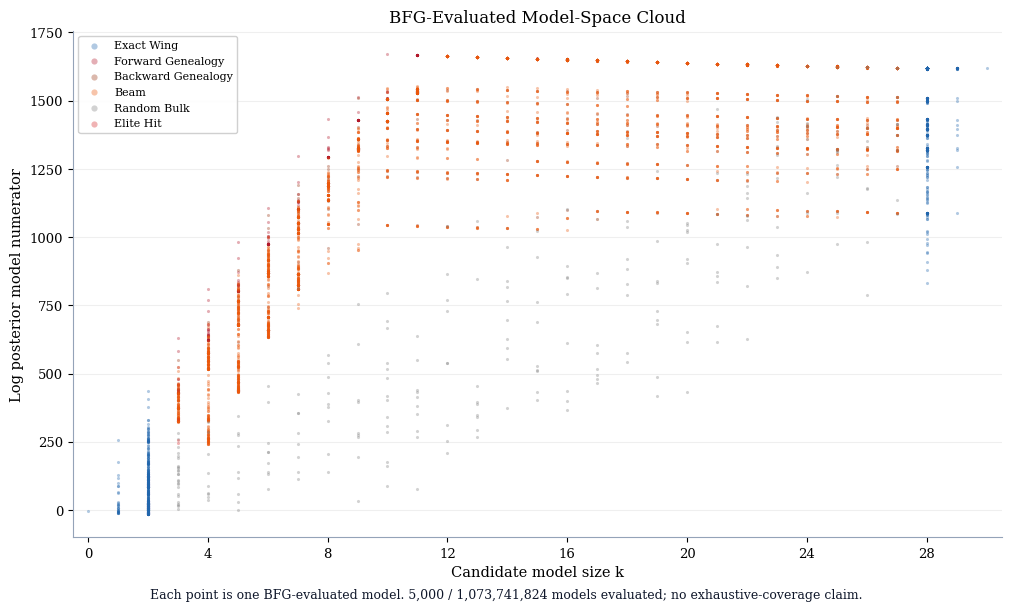

In [10]:
display(list(figures.values())[0])

## 2. Progressive cloud

Cumulative prefixes at actual ledger/stage boundaries, labeled by unique evaluation count.

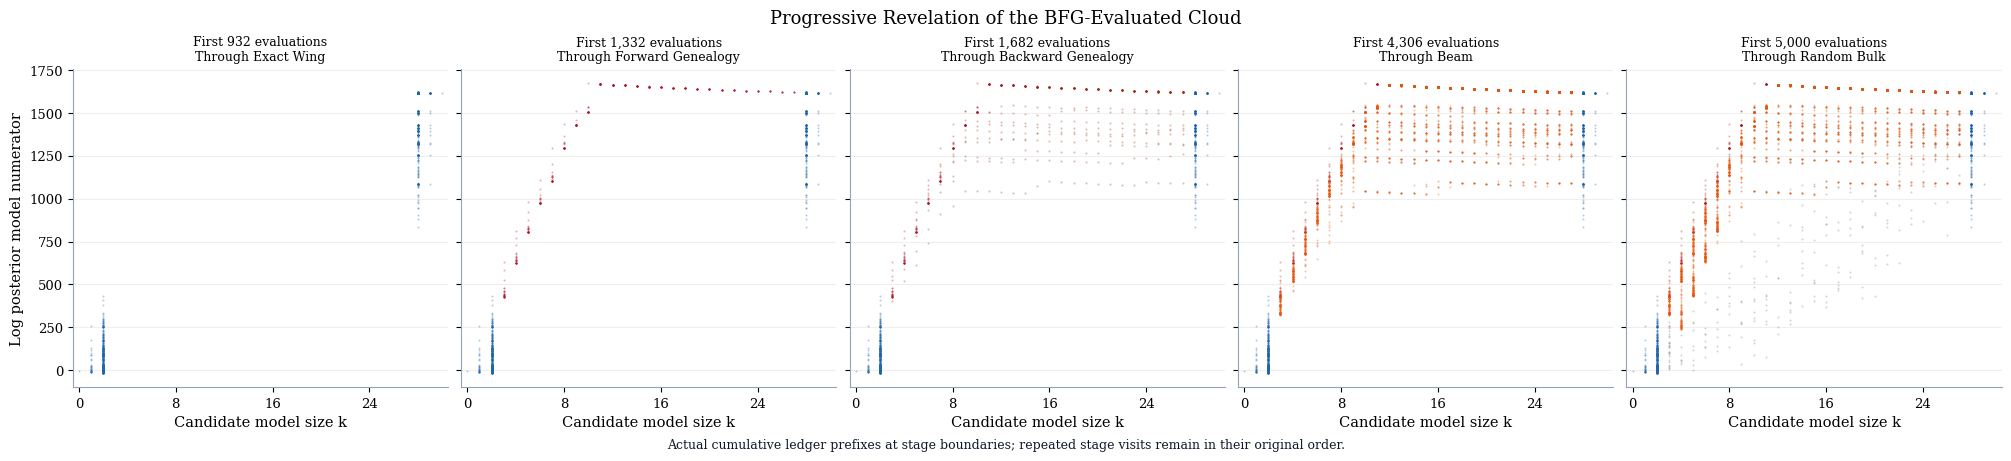

In [11]:
display(list(figures.values())[1])

## 3. Finite-support ridges and observed frontiers

Every ridge starts at the observed minimum and ends at the observed maximum of its reticula. Lower/upper frontiers and champions are from E only. Unit peak is not posterior mass. Sparse shells use spikes; KDE requires eight observations and three distinct scores.

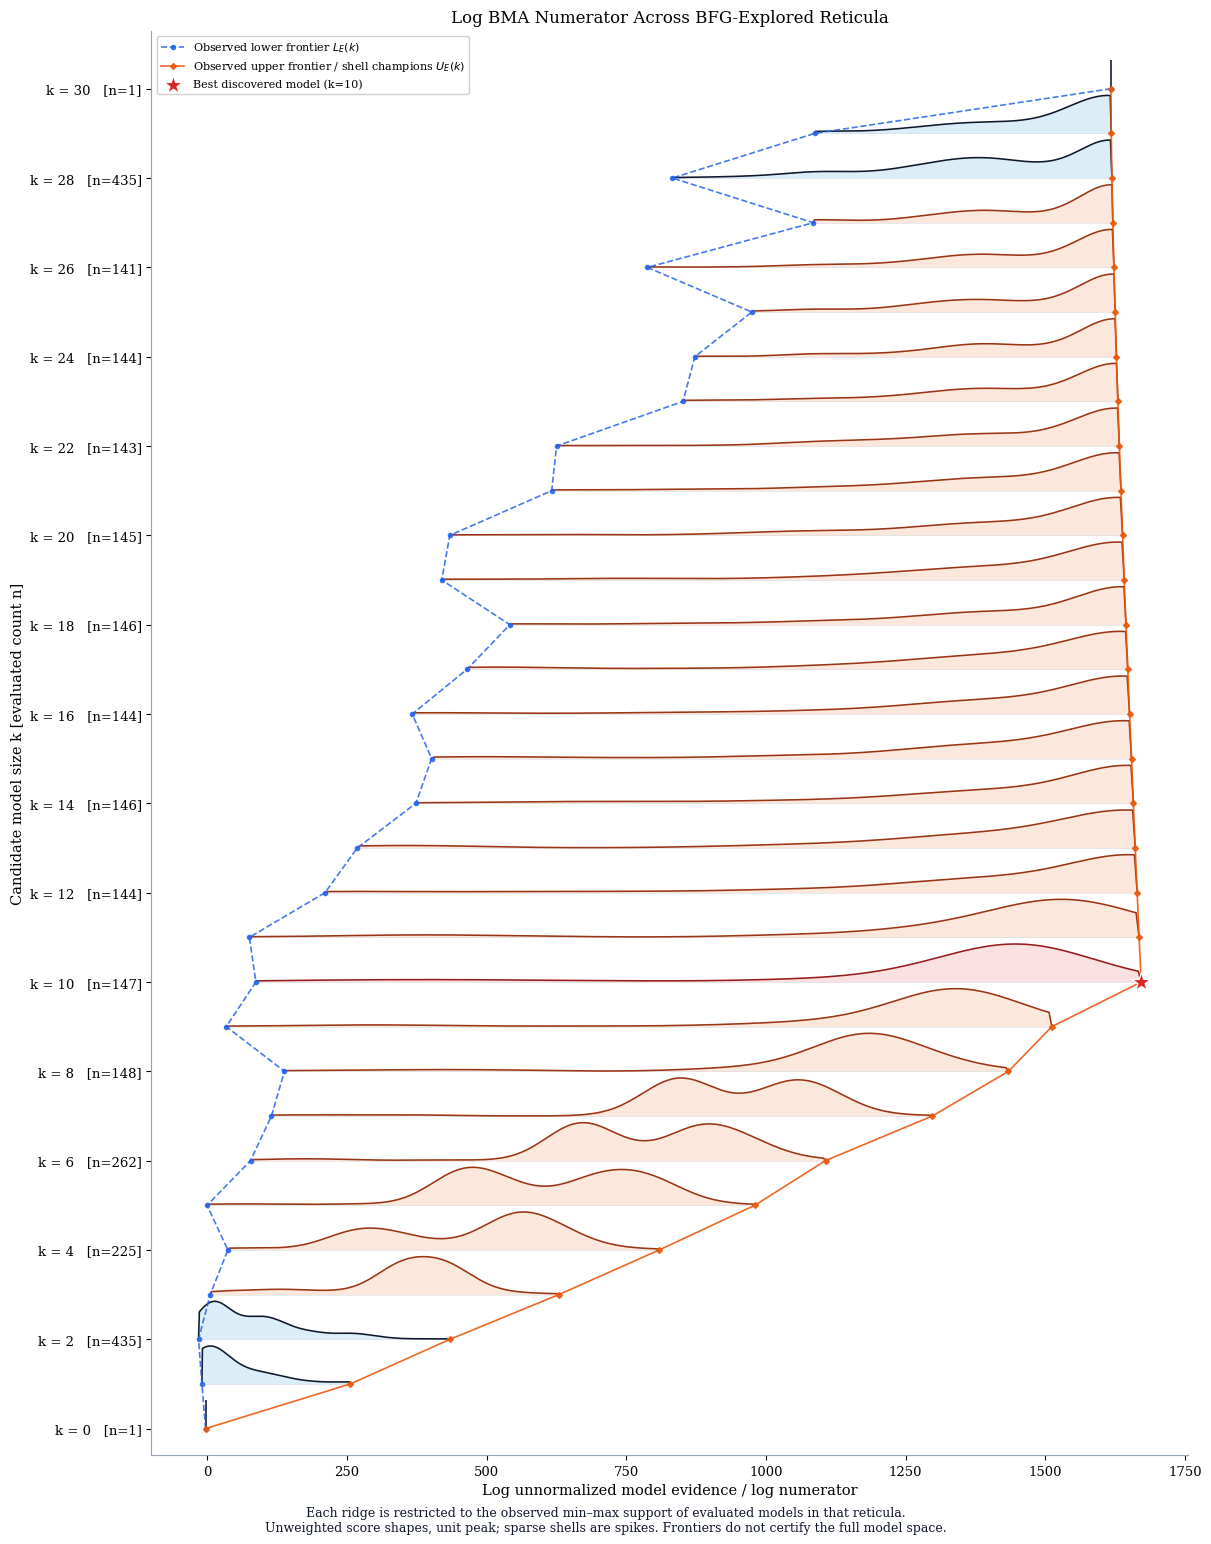

In [12]:
display(list(figures.values())[2])

## 4. Variable inclusion and model structure

The historical publication proportional map and sidebar, normalized over all E. Always-in controls are dark, labeled separately, and excluded from candidate k. Hatched remainder means other evaluated models only.

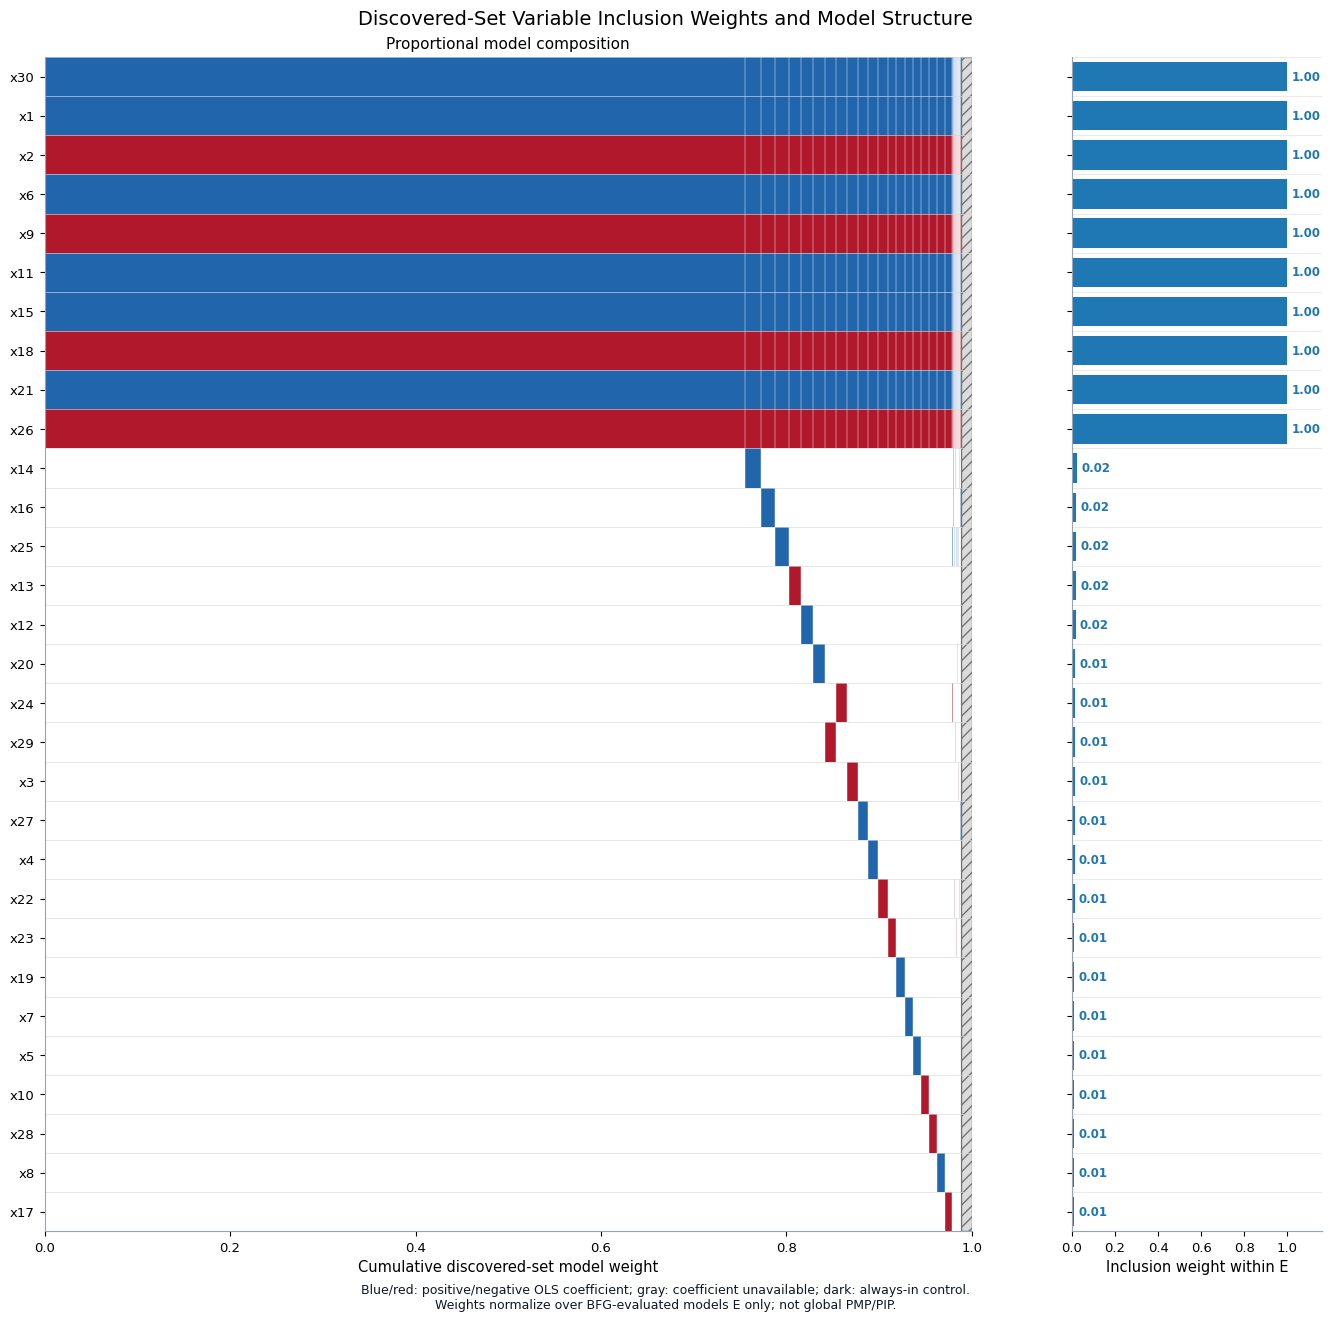

In [13]:
display(list(figures.values())[3])

## 5. Aligned top-model weights and composition

Rows match exactly: rank, candidate size, included variables and discovered-set weights. Weights are not renormalized over top K.

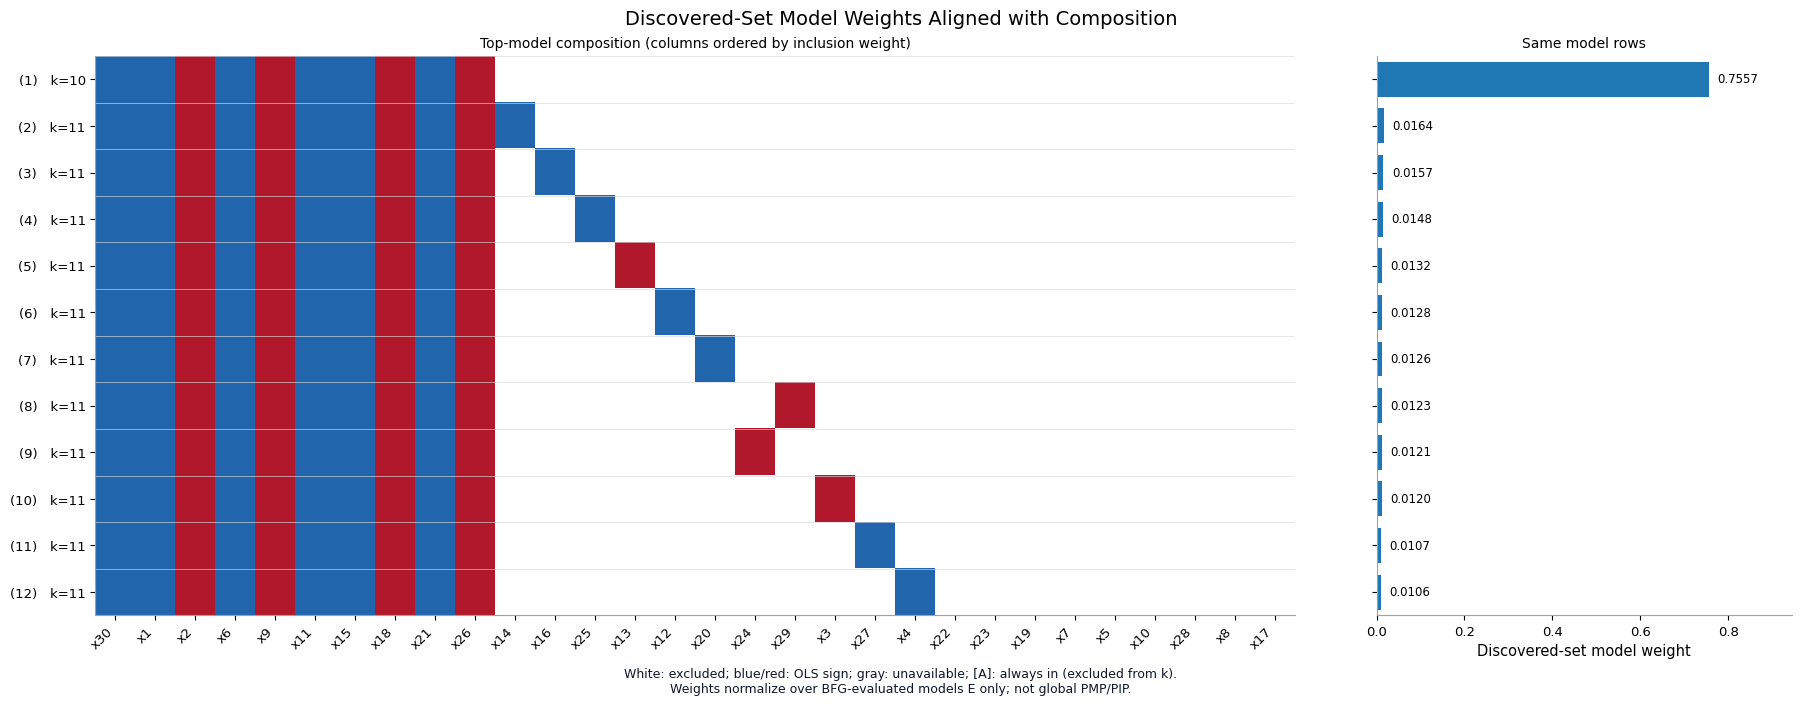

In [14]:
display(list(figures.values())[4])

## 6. Model-size distribution

Configured prior, conditional size weights, discovered-set mean and best-model size. Candidate k excludes always-in controls.

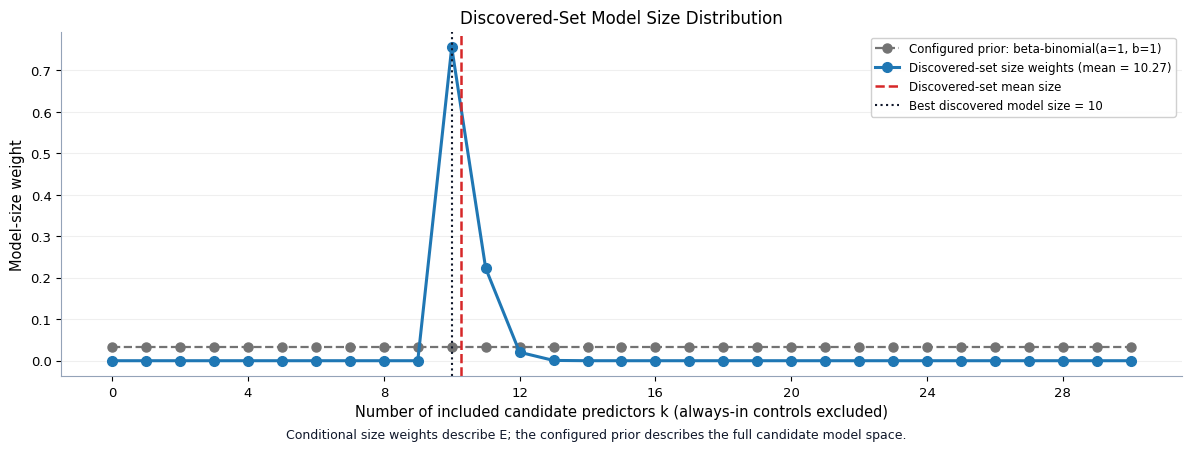

In [15]:
display(list(figures.values())[5])

## 7. Conditional coefficient structure

Empirical weighted OLS coefficient point estimates across available full-rank evaluated models, conditional on inclusion. Not posterior coefficient draws or fabricated confidence densities.

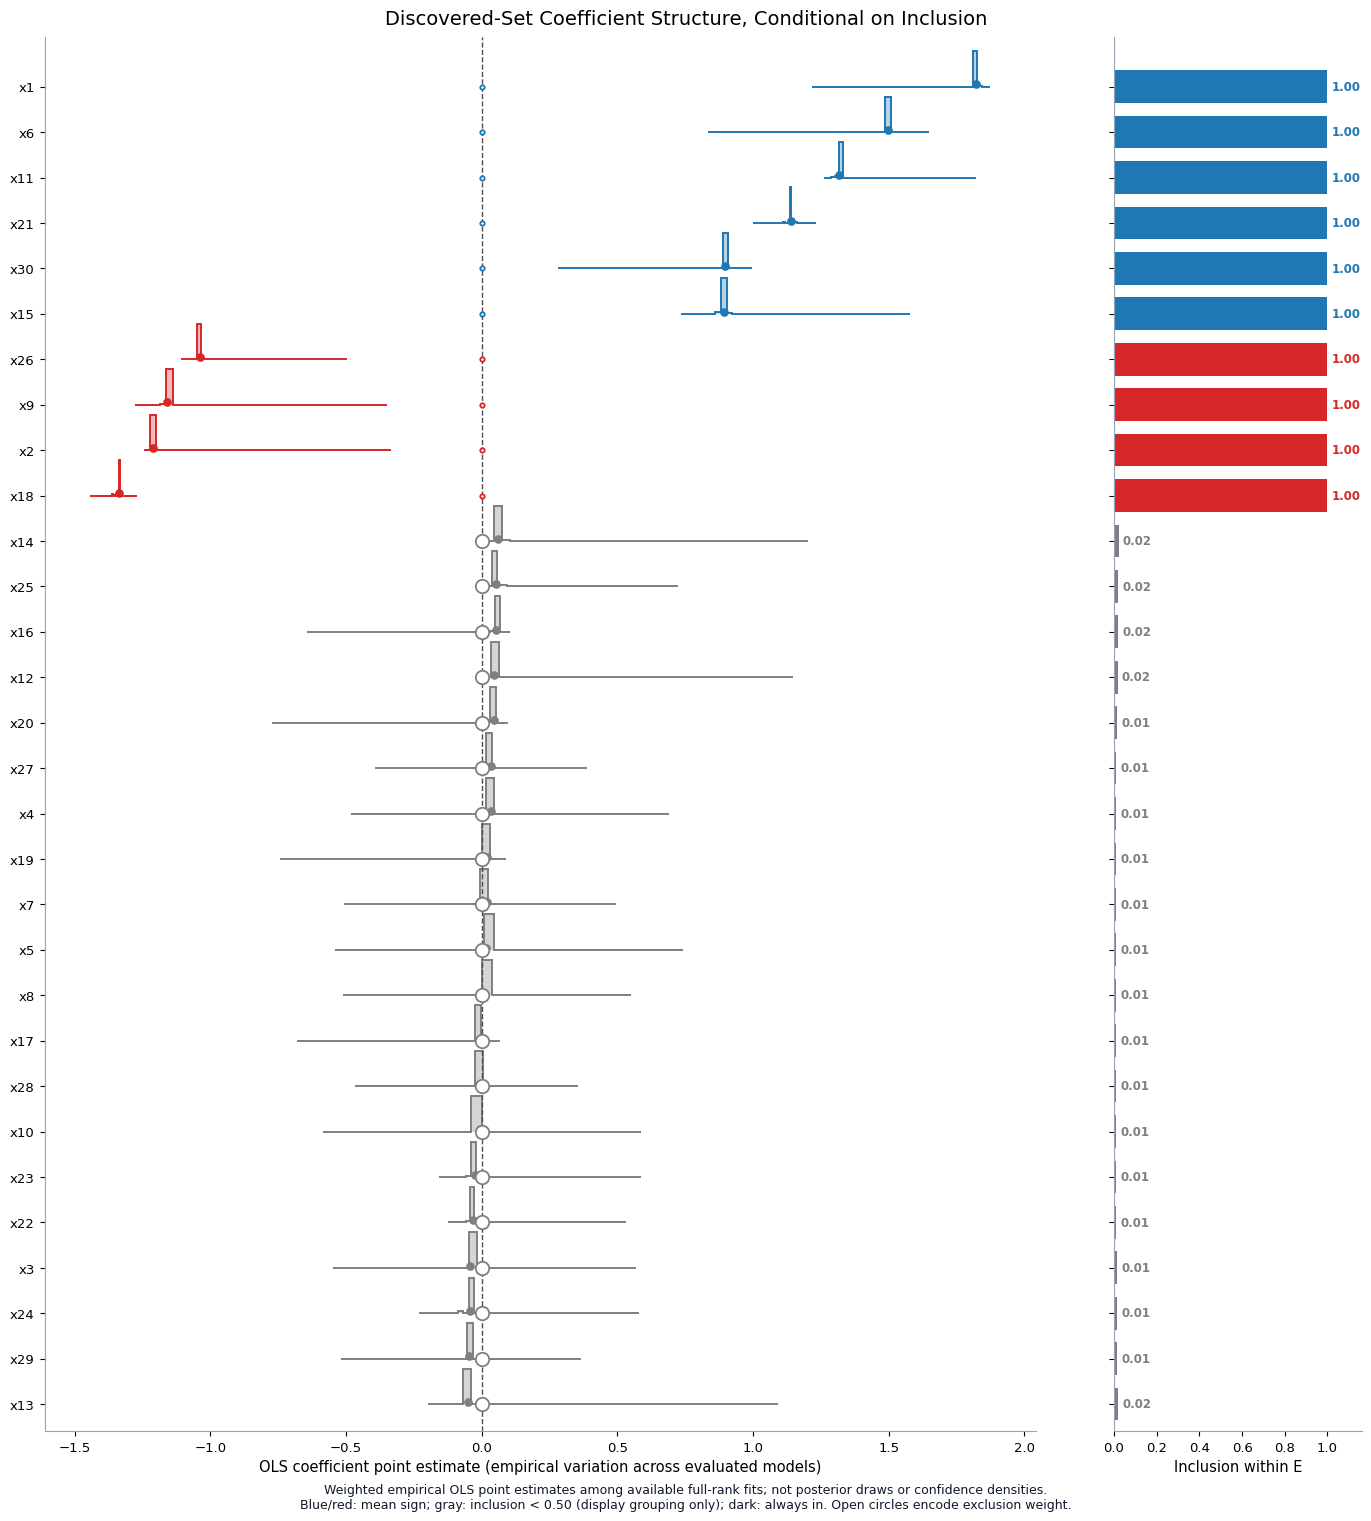

In [16]:
display(list(figures.values())[6])

## 8. Champion trajectory

A strict incumbent step function; early improvements receive a detail panel alongside full-budget context.

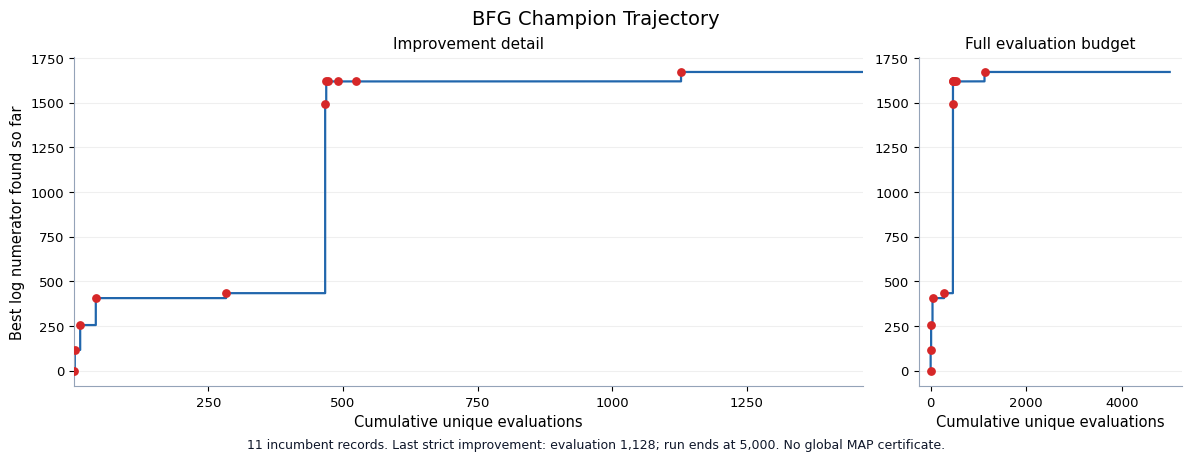

In [17]:
display(list(figures.values())[7])

## 9. Reticular search-stage map

Each unique scored model appears once. Actual stage chronology supplies information absent from the score cloud.

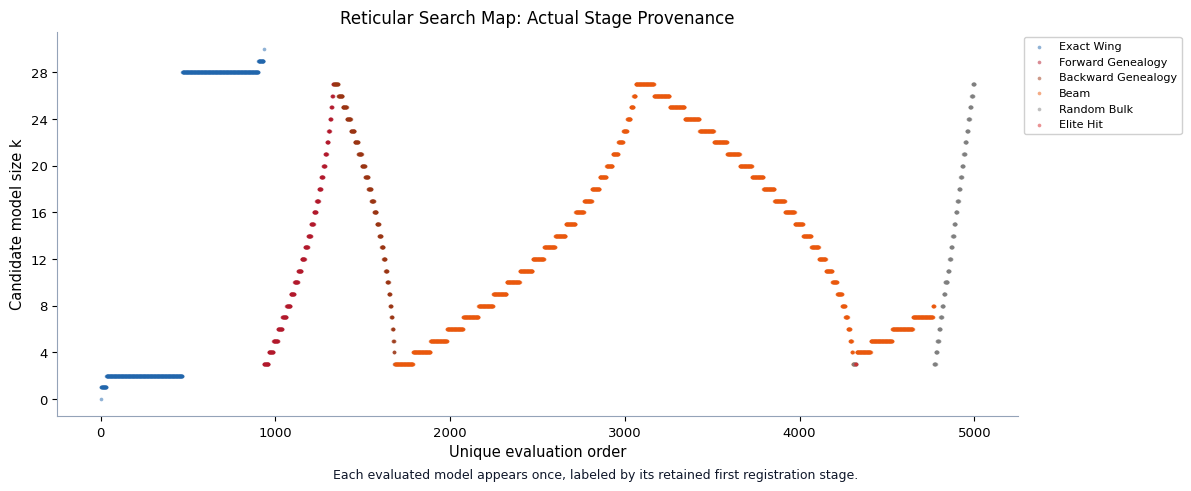

In [18]:
display(list(figures.values())[8])

## 10. Champion genealogy

Only recorded predecessor edges are shown. No missing links or universal dynasty is inferred. Supporting CSV is separate.

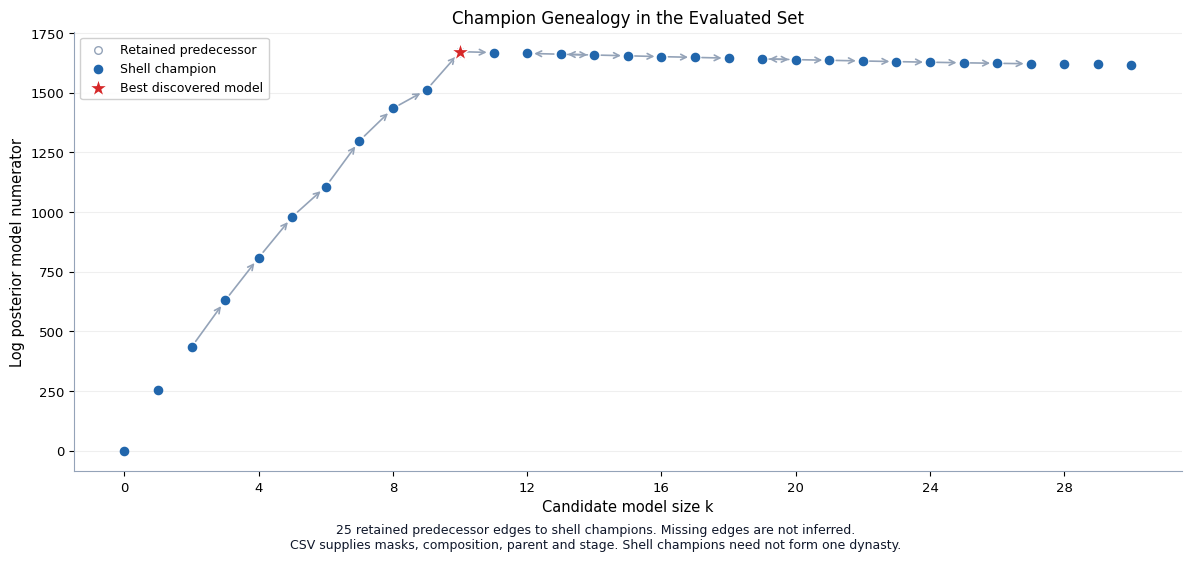

In [19]:
display(list(figures.values())[9])

## 11. Observed reticular frontiers

A standalone paper view of lower and upper evaluated-score frontiers. These are observed ranges, not exhaustive bounds.

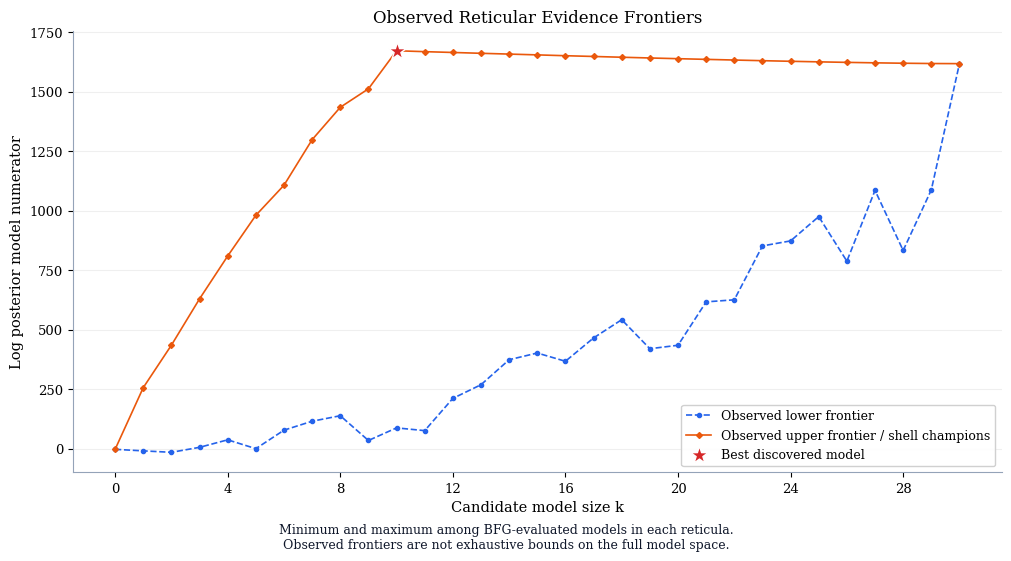

In [20]:
display(list(figures.values())[10])

## Paper-style top-five model comparison

Columns (1)–(5) remain BFG ranks 1–5. Excluded predictors are `---`; an unavailable fifth model is NA. The synthetic notebook adds a separate archived-reference panel for M* and exact MAP, with true-model size/variables, global rank/PMP, discovery status, N_TRUE/N_MAP and Hamming distance. Superscript T/M marks a top-five column only when it really is the true/exact MAP model. No model is inserted to make it appear in the top five.

The main table separates OLS diagnostics from log marginal likelihood (relative/common-constant convention), log model prior, log posterior model numerator and discovered-set normalized weight.

In [21]:
display(top5_preview.style.hide(axis="index"))
if reference is not None:
    import pandas as pd
    display(pd.DataFrame(reference_panel(result, reference), columns=["Synthetic benchmark reference", "Value"]))
print("LaTeX:", (OUTPUT_DIR/"bfg_top5_regression_comparison.tex").as_posix())


Regressor / diagnostic,(1),(2),(3),(4),(5)
Intercept,1.9009,1.9009,1.9009,1.9009,1.9009
,(0.0404),(0.0404),(0.0404),(0.0404),(0.0404)
x1,1.8227,1.8219,1.8233,1.8212,1.8225
,(0.0451),(0.0451),(0.0451),(0.0452),(0.0451)
x2,-1.2106,-1.2112,-1.2117,-1.2109,-1.2111
,(0.0451),(0.0451),(0.0451),(0.0451),(0.0451)
x3,---,---,---,---,---
x4,---,---,---,---,---
x5,---,---,---,---,---
x6,1.4993,1.4992,1.4985,1.4994,1.4979


LaTeX: bfg_example_outputs/run_20260914T083242022214Z/bfg_top5_regression_comparison.tex


## Download the output package

PNG figures, LaTeX/CSV tables, the discovery ledger and budget/runtime metadata are exported together. No PDF figure duplicates. The original small k=1 demo belonged to a smoke-test fixture, not panel_30_center15; it is no longer used for public figures.

In [22]:
import shutil
archive_path = shutil.make_archive(str(OUTPUT_DIR), "zip", root_dir=OUTPUT_DIR)
try:
    from google.colab import files
except ImportError:
    print("Output ZIP:", Path(archive_path).name)
else:
    files.download(archive_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>